# I-94 24-hour traffic forecast

**Abdulaziz AlAbdulkareem**  
SDAIA Academy · Time Series Analysis and Forecasting · 13–15 September 2026

<a href="https://colab.research.google.com/github/owAziz/time-series-analysis-and-forecasting/blob/main/capstone.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

Can I forecast the next 24 hours of westbound vehicles on I-94 (MN DoT ATR 301, Minneapolis–St Paul) well enough to be useful — and attach an 80% interval whose coverage and width I can stand behind?

I used the [UCI Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume) series, not the course synthetic files. Numbers here are this I-94 record.

Course: [Time Series Forecasting for AI Systems](https://mohammadyusif.github.io/time-series-forecasting-ai-systems/) · [SDAIA Academy](https://github.com/SDAIAAcademy)


## Setup

The first code cell installs what it needs and downloads `metrics.py` and `backtest.py` from the course repo if they are not already on disk. No API key.


In [1]:
import subprocess, sys

def _pip_install(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)

_pip_install("pandas", "numpy", "matplotlib", "scikit-learn", "lightgbm", "statsmodels", "prophet", "sktime")

import pathlib
import urllib.request

REPO = "MohammadYusif/time-series-forecasting-ai-systems"
BRANCH = "main"

def fetch(rel_path: str) -> str:
    # Local checkout first; otherwise download from the course GitHub repo.
    for candidate in (rel_path, f"../{rel_path}"):
        if pathlib.Path(candidate).exists():
            return candidate
    dest = pathlib.Path(pathlib.Path(rel_path).name)
    if not dest.exists():
        url = f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{rel_path}"
        urllib.request.urlretrieve(url, dest)
    return str(dest)

sys.path.insert(0, str(pathlib.Path(fetch("common/metrics.py")).parent))
from metrics import mae, rmse, wape, mase, coverage, interval_width, pinball_loss
sys.path.insert(0, str(pathlib.Path(fetch("common/backtest.py")).parent))
from backtest import expanding_window_splits, rolling_window_splits, run_backtest, seasonal_naive_forecast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

RNG_SEED = 20260912
np.random.seed(RNG_SEED)
print("metrics + backtest imported; seed", RNG_SEED)


metrics + backtest imported; seed 20260912


## Load and clean the series

Duplicate timestamps (several weather labels in the same hour), a 0 K temperature error, an absurd rain spike, and a long 2014–2015 gap all have to be handled before decomposition or Holt-Winters will see a regular hourly frequency.

The modelling window is **2018-01-01 through 2018-09-30**: after the historical gap, long enough for `lag_168`, short enough that an expanding-window Holt-Winters fit stays practical. Tiny holes (≤ 6 hours) are interpolated; weather used later is lagged, not contemporaneous.


In [2]:
UCI_URL = (
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00492/"
    "Metro_Interstate_Traffic_Volume.csv.gz"
)

raw = pd.read_csv(UCI_URL, compression="gzip")
print("raw rows:", len(raw), "columns:", list(raw.columns))
print(raw.head(3))

df = raw.copy()
df["date_time"] = pd.to_datetime(df["date_time"])
n_dup = df["date_time"].duplicated().sum()
df = df.sort_values("date_time").drop_duplicates("date_time", keep="first")
print("duplicate timestamps dropped:", int(n_dup))

n_temp = int((df["temp"] < 200).sum())
n_rain = int((df["rain_1h"] > 100).sum())
df.loc[df["temp"] < 200, "temp"] = np.nan
df.loc[df["rain_1h"] > 100, "rain_1h"] = np.nan
print("implausible temp (<200 K) set to NA:", n_temp)
print("implausible rain_1h (>100 mm) set to NA:", n_rain)

df = df.set_index("date_time").sort_index()
df = df.loc["2018-01-01":"2018-09-30"].copy()

full_idx = pd.date_range(df.index.min(), df.index.max(), freq="h")
n_missing = int(len(full_idx.difference(df.index)))
df = df.reindex(full_idx)
num_cols = ["temp", "rain_1h", "snow_1h", "clouds_all", "traffic_volume"]
df[num_cols] = df[num_cols].interpolate(limit=6)
df["weather_main"] = df["weather_main"].ffill(limit=6)
df["holiday"] = df["holiday"].replace({np.nan: None, "": None})

# Holiday is known calendar information: flag the whole calendar day.
holiday_mask = df["holiday"].notna() & ~df["holiday"].astype(str).isin(["None", "nan", "NaN"])
holiday_days = set(df.index[holiday_mask].normalize())
df["is_holiday"] = df.index.normalize().isin(holiday_days).astype(int)
df["temp_c"] = df["temp"] - 273.15

still_na = int(df["traffic_volume"].isna().sum())
if still_na:
    print("traffic_volume still NA after interpolate(limit=6):", still_na, "— filling remaining to keep a regular hourly index")
    df["traffic_volume"] = df["traffic_volume"].interpolate().ffill().bfill()
df[num_cols] = df[num_cols].ffill().bfill()
df = df.asfreq("h")

y = df["traffic_volume"].astype(float)
print("modelling window:", df.index.min(), "→", df.index.max())
print("hours:", len(df), "missing hours before interpolate:", n_missing)
print("inferred freq:", df.index.freq)
print("target min/mean/max:", float(y.min()), float(y.mean()), float(y.max()))


raw rows: 48204 columns: ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
duplicate timestamps dropped: 7629
implausible temp (<200 K) set to NA: 10
implausible rain_1h (>100 mm) set to NA: 1
modelling window: 2018-01-01 00:00:00 → 2018-09-30 23:00:00
hours: 6552 missing hours before interpolate: 19
inferred freq: <Hour>
target min/mean/max: 151.0 3319.195818070818 7213.0


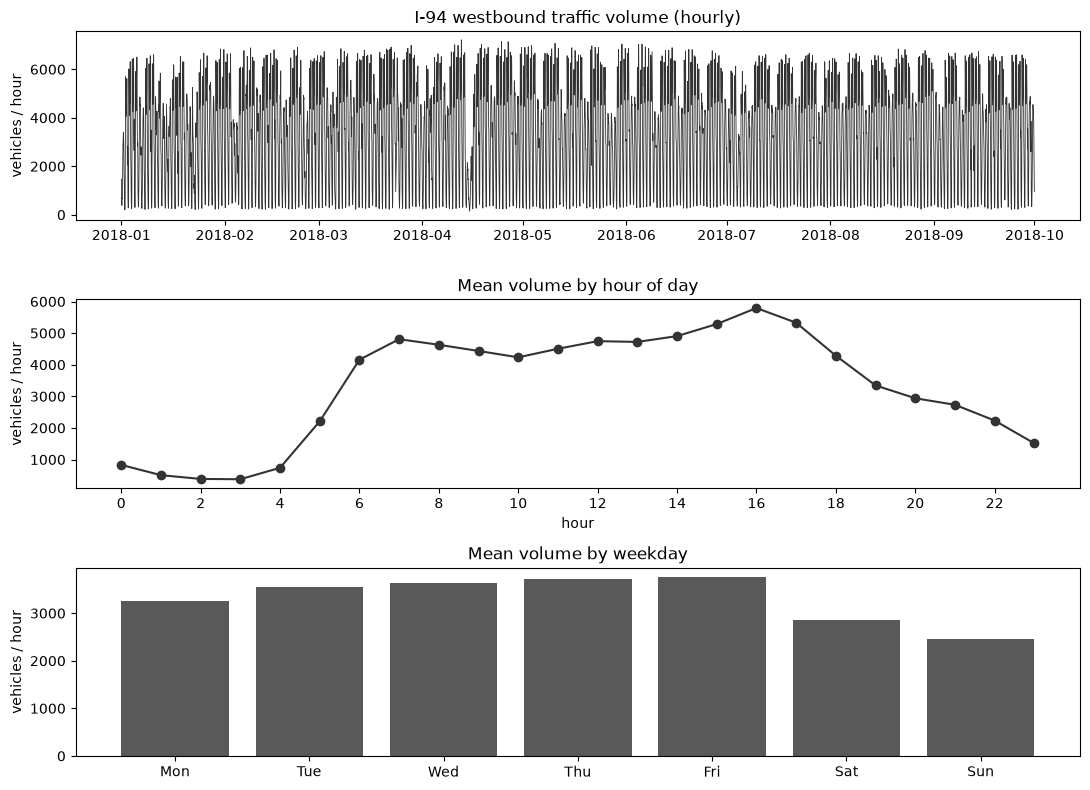

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=False)

axes[0].plot(y, color="0.2", linewidth=0.6)
axes[0].set_title("I-94 westbound traffic volume (hourly)")
axes[0].set_ylabel("vehicles / hour")

hourly = y.groupby(y.index.hour).mean()
axes[1].plot(hourly.index, hourly.values, marker="o", color="0.2")
axes[1].set_title("Mean volume by hour of day")
axes[1].set_xlabel("hour")
axes[1].set_ylabel("vehicles / hour")
axes[1].set_xticks(range(0, 24, 2))

dow = y.groupby(y.index.dayofweek).mean()
axes[2].bar(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], dow.values, color="0.35")
axes[2].set_title("Mean volume by weekday")
axes[2].set_ylabel("vehicles / hour")

fig.tight_layout()
plt.show()


## 1. Decomposition and diagnostics

STL with a 24-hour period, then ACF/PACF and an ADF test. I want to know whether the series needs differencing and what seasonal period to use.


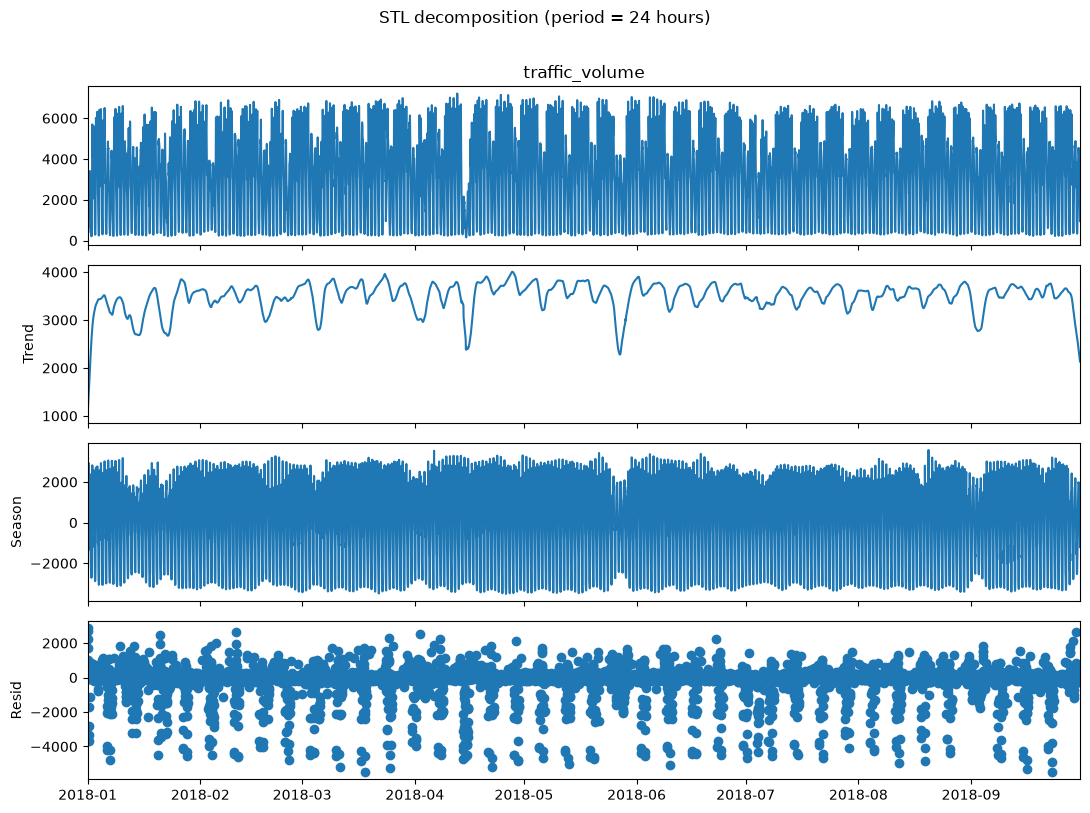

STL component stdevs — trend: 301.26785598458554 seasonal: 1964.0738501182127 resid: 861.6123902959995


In [4]:
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

stl = STL(y, period=24, robust=True)
stl_res = stl.fit()

fig = stl_res.plot()
fig.set_size_inches(11, 8)
fig.suptitle("STL decomposition (period = 24 hours)", y=1.01)
plt.tight_layout()
plt.show()

print("STL component stdevs — trend:", float(stl_res.trend.std()),
      "seasonal:", float(stl_res.seasonal.std()),
      "resid:", float(stl_res.resid.std()))


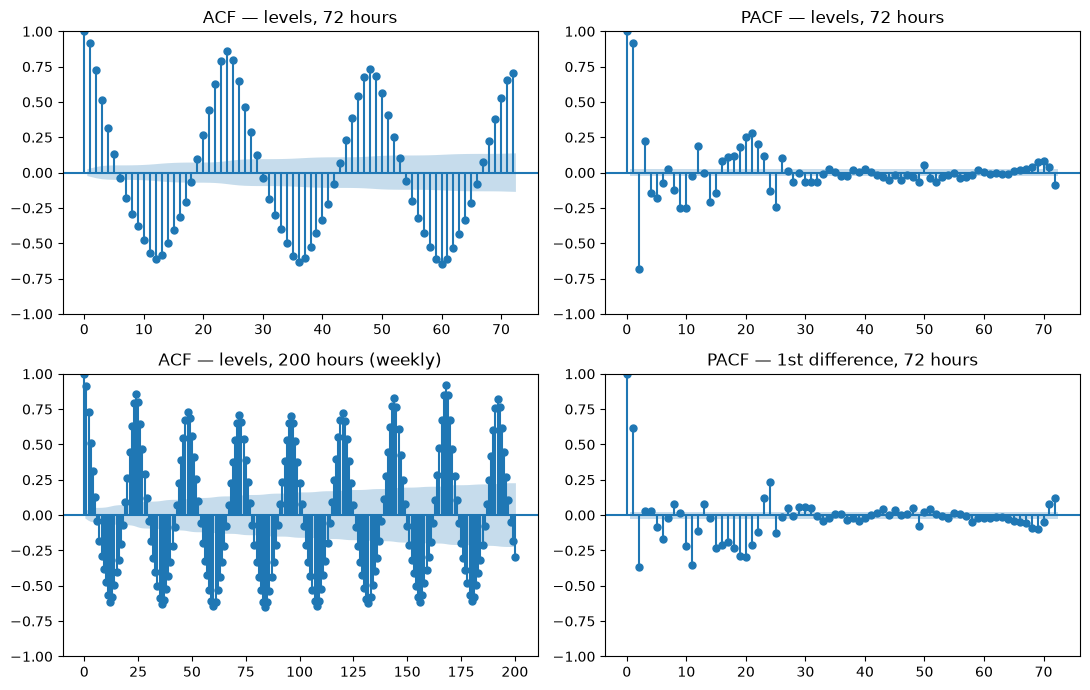

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
plot_acf(y, lags=72, ax=axes[0, 0], title="ACF — levels, 72 hours")
plot_pacf(y, lags=72, ax=axes[0, 1], title="PACF — levels, 72 hours", method="ywm")
plot_acf(y, lags=200, ax=axes[1, 0], title="ACF — levels, 200 hours (weekly)")
plot_pacf(y.diff().dropna(), lags=72, ax=axes[1, 1], title="PACF — 1st difference, 72 hours", method="ywm")
fig.tight_layout()
plt.show()


In [6]:
adf_level = adfuller(y.dropna(), autolag="AIC")
adf_diff = adfuller(y.diff().dropna(), autolag="AIC")

def _report(name, res):
    stat, pvalue, usedlag, nobs, crit, _ = res
    print(f"{name}")
    print(f"  ADF statistic: {stat:.3f}")
    print(f"  p-value:       {pvalue:.4g}")
    print(f"  used lag:      {usedlag}, nobs: {nobs}")
    print(f"  critical 1%/5%/10%: {crit['1%']:.3f} / {crit['5%']:.3f} / {crit['10%']:.3f}")
    print(f"  reject unit root at 5%? {pvalue < 0.05}")

_report("ADF on levels (traffic_volume)", adf_level)
print()
_report("ADF on first difference", adf_diff)


ADF on levels (traffic_volume)
  ADF statistic: -10.633
  p-value:       5.15e-19
  used lag:      33, nobs: 6518
  critical 1%/5%/10%: -3.431 / -2.862 / -2.567
  reject unit root at 5%? True

ADF on first difference
  ADF statistic: -18.687
  p-value:       2.04e-30
  used lag:      33, nobs: 6517
  critical 1%/5%/10%: -3.431 / -2.862 / -2.567
  reject unit root at 5%? True


C:\Users\pifnd\AppData\Local\Temp\ipykernel_21352\1038088920.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_level = adfuller(y.dropna(), autolag="AIC")
C:\Users\pifnd\AppData\Local\Temp\ipykernel_21352\1038088920.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_diff = adfuller(y.diff().dropna(), autolag="AIC")


### Reading the diagnostics

STL’s seasonal component (period 24, stdev about 1964 vehicles/hour) dwarfs the trend (stdev about 301). This is a diurnal series: rush-hour peaks and overnight troughs repeat every day. The weekday bar chart already showed a second, weekly pattern — weaker commuting on Saturday and Sunday.

The ACF in levels spikes at lags 24, 48, 72, with a slower bump near 168 hours. That is the daily cycle plus a weekly remnant, so the classical model’s seasonal period is 24 and LightGBM also gets `lag_168`.

ADF on the levels: statistic −10.633, p-value 5.15×10⁻¹⁹, well below 0.05. We reject a unit root. The series does **not** need differencing before Holt-Winters on the levels. First-difference ADF is even more decisive (p = 2.04×10⁻³⁰); that only confirms there is no leftover stochastic trend worth modelling. Hourly traffic mean-reverts around a daily seasonal profile. Treating it as a random walk would throw away the structure STL just isolated.

If levels had failed ADF we would difference once (`d = 1`) before SARIMA. They did not, so we leave the series undifferenced and use additive ETS with a period-24 seasonal.


## 2. Holt-Winters

STL showed a stable daily cycle on a slow trend, so I used Holt-Winters with additive trend, additive seasonality, and `seasonal_periods=24`. SARIMA with a 24-hour seasonal would be the same idea and a lot slower here.

Repeating the last 24 hours is the baseline, not the model. After fitting I run Ljung-Box on the residuals. Structure left at lag 24 means the seasonal piece is incomplete; leftover short-lag correlation means ETS is missing dynamics that lags might catch.


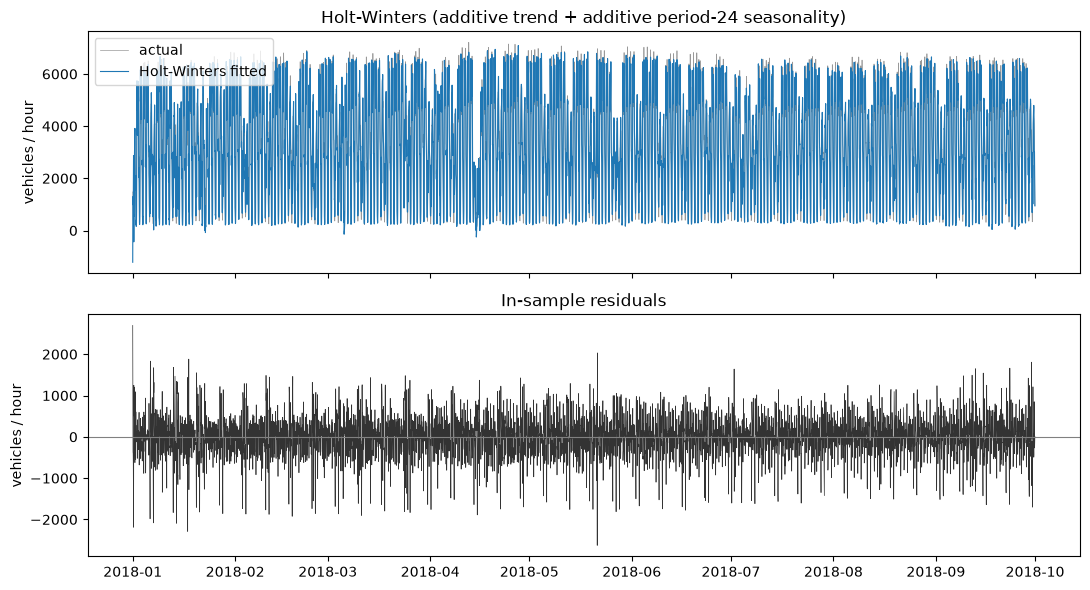

in-sample MAE: 332.1505072302129
AIC: 80724.05100040813 BIC: 80914.10171792305


In [7]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.stats.diagnostic import acorr_ljungbox

# Diagnostic fit on the full modelling window (backtest refits per fold later).
ets = ExponentialSmoothing(
    y,
    trend="add",
    seasonal="add",
    seasonal_periods=24,
    initialization_method="estimated",
)
ets_fit = ets.fit(optimized=True)
fitted = pd.Series(ets_fit.fittedvalues, index=y.index)
resid = (y - fitted).dropna()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(y, color="0.6", linewidth=0.5, label="actual")
axes[0].plot(fitted, color="C0", linewidth=0.8, label="Holt-Winters fitted")
axes[0].set_title("Holt-Winters (additive trend + additive period-24 seasonality)")
axes[0].set_ylabel("vehicles / hour")
axes[0].legend(loc="upper left")
axes[1].plot(resid, color="0.2", linewidth=0.5)
axes[1].axhline(0, color="0.5", linewidth=0.8)
axes[1].set_title("In-sample residuals")
axes[1].set_ylabel("vehicles / hour")
fig.tight_layout()
plt.show()

print("in-sample MAE:", mae(y.loc[resid.index], fitted.loc[resid.index]))
print("AIC:", float(ets_fit.aic), "BIC:", float(ets_fit.bic))


In [8]:
lb = acorr_ljungbox(resid, lags=[24, 48, 168], return_df=True)
print("Ljung-Box on Holt-Winters residuals")
print(lb)
print()
print(
    "p-values are ~0 at lags 24, 48, and 168, so the daily seasonal did not"
    " soak up everything. That leftover weekly structure is why I also fit LightGBM."
)


Ljung-Box on Holt-Winters residuals
          lb_stat  lb_pvalue
24    4198.392532        0.0
48    5093.005080        0.0
168  15647.518641        0.0

p-values are ~0 at lags 24, 48, and 168, so the daily seasonal did not soak up everything. That leftover weekly structure is why I also fit LightGBM.


## 2b. SARIMAX

ADF already rejected a unit root (p ~ 5e-19), so I set `d = 0` and `D = 0`. I then ran a small grid over `(p,0,q)(P,0,Q,24)` with p,q,P,Q in {0,1} on the last 21 days — hourly SARIMAX on the full 6,552-point series is too slow for a 16-model search. I keep Holt-Winters as the ETS fit and use the winning SARIMAX order for the backtest, fitting each fold on the last 28 days of its training window.


In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

search = y.iloc[-21 * 24 :]
rows = []
for p in (0, 1):
    for q in (0, 1):
        for P in (0, 1):
            for Q in (0, 1):
                if p == q == P == Q == 0:
                    continue
                order = (p, 0, q)
                seasonal = (P, 0, Q, 24)
                try:
                    fit = SARIMAX(
                        search,
                        order=order,
                        seasonal_order=seasonal,
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False, maxiter=40)
                    rows.append({"order": order, "seasonal": seasonal, "AIC": float(fit.aic), "BIC": float(fit.bic)})
                except Exception as exc:
                    rows.append({"order": order, "seasonal": seasonal, "AIC": float("nan"), "BIC": float("nan"), "err": str(exc)[:80]})

sarimax_grid = pd.DataFrame(rows).sort_values("AIC")
print(sarimax_grid.to_string(index=False))
best = sarimax_grid.iloc[0]
SARIMAX_ORDER = tuple(best["order"])
SARIMAX_SEASONAL = tuple(best["seasonal"])
print("selected", SARIMAX_ORDER, SARIMAX_SEASONAL)


    order      seasonal         AIC         BIC
(1, 0, 1) (1, 0, 1, 24) 7199.532562 7220.380615
(1, 0, 1) (1, 0, 0, 24) 7235.354854 7252.041657
(1, 0, 0) (1, 0, 1, 24) 7300.663695 7317.350497
(1, 0, 0) (1, 0, 0, 24) 7308.368704 7320.883806
(1, 0, 1) (0, 0, 1, 24) 7358.774942 7375.453385
(0, 0, 1) (1, 0, 1, 24) 7484.798738 7501.477181
(1, 0, 0) (0, 0, 1, 24) 7487.436321 7499.951423
(0, 0, 1) (1, 0, 0, 24) 7512.981509 7525.502867
(0, 0, 0) (1, 0, 1, 24) 7895.359098 7907.874200
(0, 0, 0) (1, 0, 0, 24) 7908.295372 7916.642944
(1, 0, 1) (0, 0, 0, 24) 7976.987425 7989.643226
(0, 0, 1) (0, 0, 1, 24) 8183.301495 8195.810327
(1, 0, 0) (0, 0, 0, 24) 8212.633105 8221.074285
(0, 0, 0) (0, 0, 1, 24) 8731.914768 8740.258170
(0, 0, 1) (0, 0, 0, 24) 9104.626473 9113.063673
selected (1, 0, 1) (1, 0, 1, 24)


In [10]:
sarimax_diag = SARIMAX(
    y.iloc[-60 * 24 :],
    order=SARIMAX_ORDER,
    seasonal_order=SARIMAX_SEASONAL,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=80)
print("in-sample AIC:", float(sarimax_diag.aic), "BIC:", float(sarimax_diag.bic))
sarimax_resid = pd.Series(sarimax_diag.resid).dropna()
lb_s = acorr_ljungbox(sarimax_resid, lags=[24, 48, 168], return_df=True)
print("Ljung-Box on SARIMAX residuals")
print(lb_s)


in-sample AIC: 20910.19927047249 BIC: 20936.470159704775
Ljung-Box on SARIMAX residuals
         lb_stat      lb_pvalue
24    345.356849   1.105559e-58
48    454.606880   1.314945e-67
168  1564.133353  8.801136e-225


## 3. LightGBM and features

A tree does not pick up seasonality on its own. I built lags, rolling stats, and calendar columns by hand.

How I avoided leaking the future:

- `lag_1`, `lag_24`, `lag_168` are shifts of volume. Rolling mean/std use `y.shift(1)`, so the current hour is never a feature for itself.
- Weather is lagged one hour. I am not assuming I already know the next day's rain.
- Hour, weekday, month, and holidays are calendar — those are known ahead of time.
- The 24-hour forecast is recursive: each step feeds the prediction back into the lags. Test-window actuals are not used.


In [11]:
FEATURE_COLS = [
    "lag_1", "lag_24", "lag_168",
    "roll_mean_24", "roll_std_24", "roll_mean_168",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "hour", "weekday", "month", "is_weekend", "is_holiday",
    "temp_lag1", "rain_lag1", "snow_lag1", "clouds_lag1",
]


def make_feature_frame(frame: pd.DataFrame) -> pd.DataFrame:
    # Rolling stats use y.shift(1); weather is lagged. No current-hour target.
    out = pd.DataFrame(index=frame.index)
    vol = frame["traffic_volume"].astype(float)
    out["traffic_volume"] = vol
    out["lag_1"] = vol.shift(1)
    out["lag_24"] = vol.shift(24)
    out["lag_168"] = vol.shift(168)
    shifted = vol.shift(1)
    out["roll_mean_24"] = shifted.rolling(24).mean()
    out["roll_std_24"] = shifted.rolling(24).std()
    out["roll_mean_168"] = shifted.rolling(168).mean()
    hour = frame.index.hour
    weekday = frame.index.weekday
    out["hour"] = hour
    out["weekday"] = weekday
    out["month"] = frame.index.month
    out["is_weekend"] = (weekday >= 5).astype(int)
    out["is_holiday"] = frame["is_holiday"].astype(int)
    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * weekday / 7)
    out["dow_cos"] = np.cos(2 * np.pi * weekday / 7)
    out["temp_lag1"] = frame["temp"].shift(1)
    out["rain_lag1"] = frame["rain_1h"].shift(1)
    out["snow_lag1"] = frame["snow_1h"].shift(1)
    out["clouds_lag1"] = frame["clouds_all"].shift(1)
    return out


feat_all = make_feature_frame(df)
print("feature rows before dropna:", len(feat_all))
print("rows lost to lag/rolling warmup:", int(feat_all[FEATURE_COLS].isna().any(axis=1).sum()))
print(feat_all[FEATURE_COLS + ["traffic_volume"]].dropna().head(3))


feature rows before dropna: 6552
rows lost to lag/rolling warmup: 168
                      lag_1  lag_24  lag_168  roll_mean_24  roll_std_24  \
2018-01-08 00:00:00  1073.0  1053.0   1478.0   2237.333333  1476.163702   
2018-01-08 01:00:00   455.0   648.0   1408.0   2212.416667  1501.847121   
2018-01-08 02:00:00   289.0   540.0    931.0   2197.458333  1519.786769   

                     roll_mean_168  hour_sin  hour_cos  dow_sin  dow_cos  \
2018-01-08 00:00:00    2918.196429  0.000000  1.000000      0.0      1.0   
2018-01-08 01:00:00    2912.107143  0.258819  0.965926      0.0      1.0   
2018-01-08 02:00:00    2905.446429  0.500000  0.866025      0.0      1.0   

                     hour  weekday  month  is_weekend  is_holiday  temp_lag1  \
2018-01-08 00:00:00     0        0      1           0           0     272.56   
2018-01-08 01:00:00     1        0      1           0           0     272.36   
2018-01-08 02:00:00     2        0      1           0           0     271.21   

   

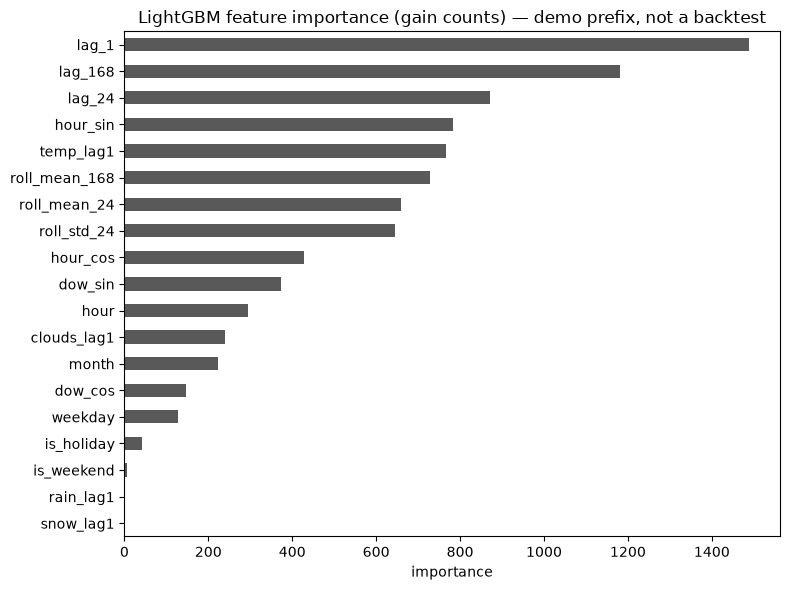

lag_1            1488
lag_168          1182
lag_24            871
hour_sin          782
temp_lag1         766
roll_mean_168     728
roll_mean_24      658
roll_std_24       646
hour_cos          427
dow_sin           374
dtype: int32


In [12]:
import lightgbm as lgb

demo = feat_all.dropna(subset=FEATURE_COLS + ["traffic_volume"])
# A single expanding prefix (not the backtest) so we can inspect importances.
cut = int(len(demo) * 0.85)
X_demo, y_demo = demo[FEATURE_COLS].iloc[:cut], demo["traffic_volume"].iloc[:cut]
lgb_demo = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RNG_SEED,
    verbose=-1,
)
lgb_demo.fit(X_demo, y_demo)
imp = pd.Series(lgb_demo.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
imp.plot.barh(ax=ax, color="0.35")
ax.set_title("LightGBM feature importance (gain counts) — demo prefix, not a backtest")
ax.set_xlabel("importance")
fig.tight_layout()
plt.show()
print(imp.sort_values(ascending=False).head(10))


## 4. Walk-forward backtest (expanding and rolling)

A single train/test cut is not a backtest. I run two designs from `common/backtest.py`, both with 4 folds and a 24-hour horizon:

- **Expanding** — train always starts at the beginning and grows.
- **Rolling** — train is a fixed 90-day window that slides forward.

I-94 looks stable in 2018, so I expected expanding to win. Rolling is here so that guess is tested, not assumed. Seasonal-naive and Holt-Winters go through `run_backtest`. LightGBM, SARIMAX, Prophet, and sktime use the same slices.


In [13]:
HORIZON = 24
N_FOLDS = 4
MIN_TRAIN = 90 * 24
PERIOD = 24
TRAIN_SIZE = MIN_TRAIN  # rolling window length

n = len(y)
expanding_splits = expanding_window_splits(n, n_folds=N_FOLDS, horizon=HORIZON, min_train_size=MIN_TRAIN)
rolling_splits = rolling_window_splits(n, n_folds=N_FOLDS, horizon=HORIZON, train_size=TRAIN_SIZE)
print("n =", n)
print("expanding required", MIN_TRAIN + N_FOLDS * HORIZON)
print("rolling required", TRAIN_SIZE + N_FOLDS * HORIZON)
for name, splits in [("expanding", expanding_splits), ("rolling", rolling_splits)]:
    print(name)
    for i, (tr, te) in enumerate(splits):
        print(
            f"  fold {i}: train[{tr.start}:{tr.stop}] ({tr.stop - tr.start} h) "
            f"test[{te.start}:{te.stop}] {y.index[te][0]} -> {y.index[te][-1]}"
            f"  overlap={not (tr.stop <= te.start)}"
        )
    assert all(tr.stop <= te.start for tr, te in splits)
splits = expanding_splits  # default for later cells that say `splits`


n = 6552
expanding required 2256
rolling required 2256
expanding
  fold 0: train[0:6456] (6456 h) test[6456:6480] 2018-09-27 00:00:00 -> 2018-09-27 23:00:00  overlap=False
  fold 1: train[0:6480] (6480 h) test[6480:6504] 2018-09-28 00:00:00 -> 2018-09-28 23:00:00  overlap=False
  fold 2: train[0:6504] (6504 h) test[6504:6528] 2018-09-29 00:00:00 -> 2018-09-29 23:00:00  overlap=False
  fold 3: train[0:6528] (6528 h) test[6528:6552] 2018-09-30 00:00:00 -> 2018-09-30 23:00:00  overlap=False
rolling
  fold 0: train[4296:6456] (2160 h) test[6456:6480] 2018-09-27 00:00:00 -> 2018-09-27 23:00:00  overlap=False
  fold 1: train[4320:6480] (2160 h) test[6480:6504] 2018-09-28 00:00:00 -> 2018-09-28 23:00:00  overlap=False
  fold 2: train[4344:6504] (2160 h) test[6504:6528] 2018-09-29 00:00:00 -> 2018-09-29 23:00:00  overlap=False
  fold 3: train[4368:6528] (2160 h) test[6528:6552] 2018-09-30 00:00:00 -> 2018-09-30 23:00:00  overlap=False


In [14]:
y_arr = y.to_numpy(dtype=float)
SARIMAX_TRAIN_TAIL = 28 * 24


def fit_predict_naive(y_train, horizon):
    return seasonal_naive_forecast(y_train, horizon, period=PERIOD)


def fit_predict_hw(y_train, horizon):
    model = ExponentialSmoothing(
        y_train,
        trend="add",
        seasonal="add",
        seasonal_periods=PERIOD,
        initialization_method="estimated",
    )
    fit = model.fit(optimized=True)
    return np.asarray(fit.forecast(horizon), dtype=float)


def fit_predict_sarimax(y_train, horizon):
    tail = y_train[-SARIMAX_TRAIN_TAIL:] if len(y_train) > SARIMAX_TRAIN_TAIL else y_train
    fit = SARIMAX(
        tail,
        order=SARIMAX_ORDER,
        seasonal_order=SARIMAX_SEASONAL,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=50)
    return np.asarray(fit.forecast(horizon), dtype=float)


print("expanding: seasonal-naive, Holt-Winters, SARIMAX")
bt_naive = run_backtest(y_arr, expanding_splits, fit_predict_naive)
bt_hw = run_backtest(y_arr, expanding_splits, fit_predict_hw)
bt_sarimax = run_backtest(y_arr, expanding_splits, fit_predict_sarimax)
print("expanding classical folds:", len(bt_hw))


expanding: seasonal-naive, Holt-Winters, SARIMAX


expanding classical folds: 4


In [15]:
def recursive_lgb_forecast(train_frame: pd.DataFrame, future_index: pd.DatetimeIndex) -> np.ndarray:
    # Fit on train only; recurse with known calendar and persisted last weather.
    feat = make_feature_frame(train_frame).dropna(subset=FEATURE_COLS + ["traffic_volume"])
    model = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RNG_SEED,
        verbose=-1,
    )
    model.fit(feat[FEATURE_COLS], feat["traffic_volume"])

    history = train_frame.copy()
    last_weather = {
        "temp": float(history["temp"].iloc[-1]),
        "rain_1h": float(history["rain_1h"].iloc[-1]),
        "snow_1h": float(history["snow_1h"].iloc[-1]),
        "clouds_all": float(history["clouds_all"].iloc[-1]),
    }
    preds = []
    for ts in future_index:
        row = {
            "traffic_volume": np.nan,  # placeholder; features use lags only
            "temp": last_weather["temp"],
            "rain_1h": last_weather["rain_1h"],
            "snow_1h": last_weather["snow_1h"],
            "clouds_all": last_weather["clouds_all"],
            "is_holiday": int(df.loc[ts, "is_holiday"]) if ts in df.index else 0,
        }
        tmp = pd.concat([history, pd.DataFrame([row], index=[ts])])
        tmp.index = pd.to_datetime(tmp.index)
        frow = make_feature_frame(tmp).iloc[[-1]]
        yhat = float(model.predict(frow[FEATURE_COLS])[0])
        preds.append(yhat)
        new = pd.DataFrame(
            {
                "traffic_volume": [yhat],
                "temp": [last_weather["temp"]],
                "rain_1h": [last_weather["rain_1h"]],
                "snow_1h": [last_weather["snow_1h"]],
                "clouds_all": [last_weather["clouds_all"]],
                "is_holiday": [row["is_holiday"]],
            },
            index=[ts],
        )
        history = pd.concat([history, new])
    return np.asarray(preds, dtype=float)


bt_lgb = []
print("running LightGBM recursive backtest on the same slices…")
for fold_idx, (tr, te) in enumerate(splits):
    train_frame = df.iloc[tr]
    future_index = df.index[te]
    y_pred = recursive_lgb_forecast(train_frame, future_index)
    bt_lgb.append(
        {
            "fold": fold_idx,
            "y_train": y_arr[tr],
            "y_true": y_arr[te],
            "y_pred": y_pred,
        }
    )
    print("  fold", fold_idx, "done")
print("LightGBM folds:", len(bt_lgb))


running LightGBM recursive backtest on the same slices…


  fold 0 done


  fold 1 done


  fold 2 done


  fold 3 done
LightGBM folds: 4


In [16]:
print("rolling: seasonal-naive, Holt-Winters, SARIMAX")
bt_naive_roll = run_backtest(y_arr, rolling_splits, fit_predict_naive)
bt_hw_roll = run_backtest(y_arr, rolling_splits, fit_predict_hw)
bt_sarimax_roll = run_backtest(y_arr, rolling_splits, fit_predict_sarimax)

bt_lgb_roll = []
print("rolling LightGBM")
for fold_idx, (tr, te) in enumerate(rolling_splits):
    y_pred = recursive_lgb_forecast(df.iloc[tr], df.index[te])
    bt_lgb_roll.append({"fold": fold_idx, "y_train": y_arr[tr], "y_true": y_arr[te], "y_pred": y_pred})
    print("  fold", fold_idx, "done")
print("rolling LightGBM folds:", len(bt_lgb_roll))


rolling: seasonal-naive, Holt-Winters, SARIMAX


rolling LightGBM


  fold 0 done


  fold 1 done


  fold 2 done


  fold 3 done
rolling LightGBM folds: 4


## 5. MAE, RMSE, and MASE

MAE and RMSE are in vehicles per hour. I also report MASE with period 24, scaled against yesterday's hourly profile on the training window. Below 1 means the model beat that naive repeat.

Volume here is almost never zero, so MAPE would not blow up — I still prefer MASE because it is already compared to the same seasonal-naive baseline.


In [17]:
def score_fold(result, period=PERIOD):
    yt, yp, ytr = result["y_true"], result["y_pred"], result["y_train"]
    return {
        "fold": result["fold"],
        "MAE": mae(yt, yp),
        "RMSE": rmse(yt, yp),
        "MASE": mase(yt, yp, ytr, seasonal_period=period),
        "WAPE": wape(yt, yp),
    }


def score_table(bt, name):
    rows = [score_fold(r) for r in bt]
    tab = pd.DataFrame(rows).set_index("fold")
    tab.loc["mean"] = tab.mean()
    print(f"\n{name}")
    print(tab.round(3).to_string())
    return tab


print("=== expanding ===")
tab_naive = score_table(bt_naive, "seasonal-naive")
tab_hw = score_table(bt_hw, "Holt-Winters")
tab_sarimax = score_table(bt_sarimax, "SARIMAX")
tab_lgb = score_table(bt_lgb, "LightGBM")

print("\n=== rolling ===")
tab_naive_r = score_table(bt_naive_roll, "seasonal-naive")
tab_hw_r = score_table(bt_hw_roll, "Holt-Winters")
tab_sarimax_r = score_table(bt_sarimax_roll, "SARIMAX")
tab_lgb_r = score_table(bt_lgb_roll, "LightGBM")

cmp = pd.DataFrame(
    {
        "expanding_MASE": [
            tab_naive.loc["mean", "MASE"],
            tab_hw.loc["mean", "MASE"],
            tab_sarimax.loc["mean", "MASE"],
            tab_lgb.loc["mean", "MASE"],
        ],
        "rolling_MASE": [
            tab_naive_r.loc["mean", "MASE"],
            tab_hw_r.loc["mean", "MASE"],
            tab_sarimax_r.loc["mean", "MASE"],
            tab_lgb_r.loc["mean", "MASE"],
        ],
    },
    index=["seasonal-naive", "Holt-Winters", "SARIMAX", "LightGBM"],
)
print("\nMean MASE, expanding vs rolling")
print(cmp.round(3).to_string())
print(
    "I would deploy the expanding window. 2018 I-94 does not look like a regime-change series,"
    " and throwing away early history did not help."
)


=== expanding ===

seasonal-naive
           MAE      RMSE   MASE    WAPE
fold                                   
0      146.083   226.970  0.257   3.991
1      344.458   577.598  0.607   8.936
2     1001.833  1536.175  1.768  33.199
3      540.292   800.548  0.951  21.575
mean   508.167   785.323  0.896  16.925

Holt-Winters
           MAE      RMSE   MASE     WAPE
fold                                    
0      549.131   772.706  0.965   15.003
1      667.092   858.010  1.176   17.305
2     2430.304  2648.299  4.290   80.536
3     3178.667  3376.941  5.595  126.929
mean  1706.299  1913.989  3.006   59.943

SARIMAX
           MAE      RMSE   MASE    WAPE
fold                                   
0      318.631   450.985  0.560   8.705
1      338.621   530.876  0.597   8.784
2     1347.932  1714.746  2.379  44.668
3     1532.810  1928.737  2.698  61.207
mean   884.498  1156.336  1.559  30.841

LightGBM
          MAE     RMSE   MASE    WAPE
fold                                 
0     129.

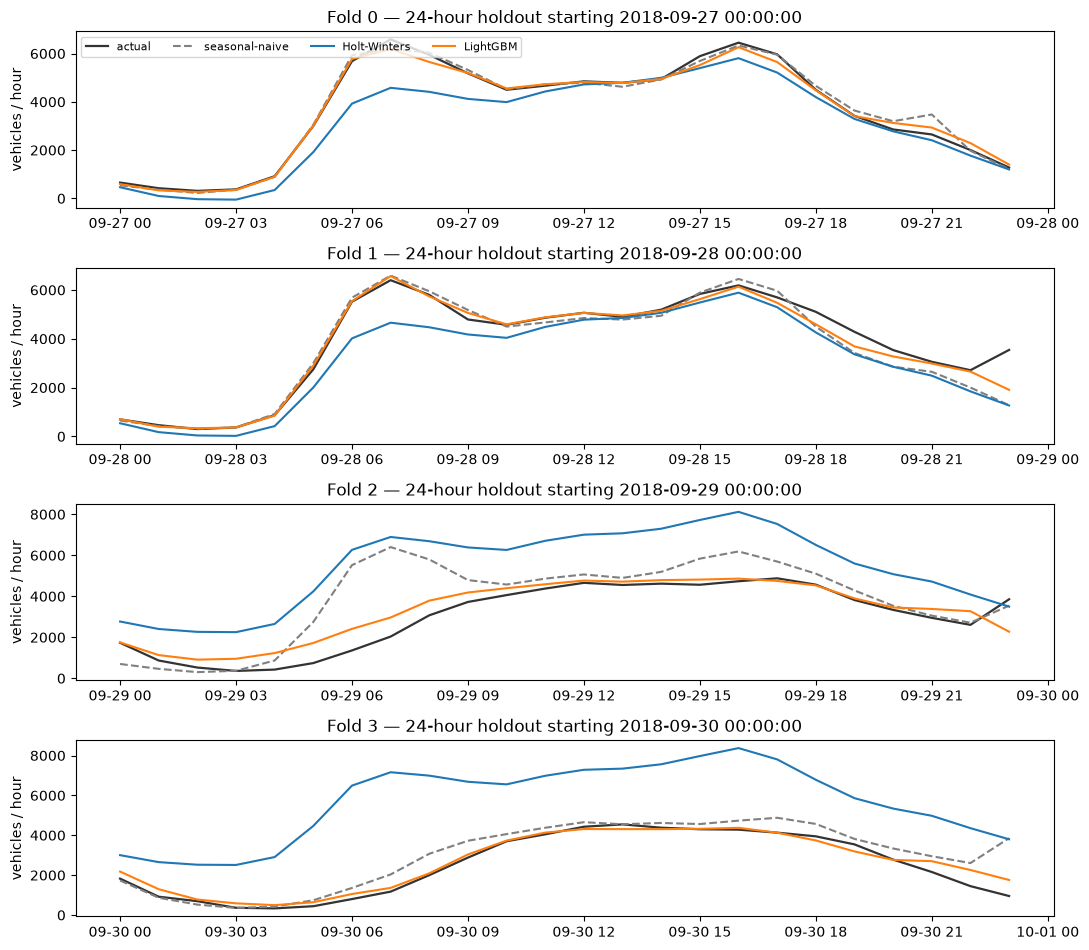

In [18]:
fig, axes = plt.subplots(N_FOLDS, 1, figsize=(11, 2.4 * N_FOLDS), sharex=False)
if N_FOLDS == 1:
    axes = [axes]
idx = y.index
for i, (tr, te) in enumerate(splits):
    ax = axes[i]
    t_te = idx[te]
    ax.plot(t_te, bt_naive[i]["y_true"], color="0.2", linewidth=1.6, label="actual")
    ax.plot(t_te, bt_naive[i]["y_pred"], "--", color="0.5", label="seasonal-naive")
    ax.plot(t_te, bt_hw[i]["y_pred"], color="C0", label="Holt-Winters")
    ax.plot(t_te, bt_lgb[i]["y_pred"], color="C1", label="LightGBM")
    ax.set_title(f"Fold {i} — 24-hour holdout starting {t_te[0]}")
    ax.set_ylabel("vehicles / hour")
    if i == 0:
        ax.legend(loc="upper left", ncol=4, fontsize=8)
fig.tight_layout()
plt.show()


## 6. Prediction intervals

Three interval sources, all scored with `coverage()` and `interval_width()` against a nominal 80% level:

1. **Conformal** around LightGBM (no native interval).
2. **Prophet** — its own `yhat_lower` / `yhat_upper`.
3. **sktime** `NaiveForecaster(sp=24)` via `predict_interval` / `predict_quantiles`, with pinball loss on the quantiles.

Coverage without width can hide a uselessly wide band.


In [19]:
CALIB_HOURS = 7 * 24
NOMINAL = 0.80
Q = 0.5 + NOMINAL / 2  # 0.90 → symmetric 80% interval from |residual|


def conformal_for_fold(train_frame, future_index, y_true, y_pred):
    if len(train_frame) <= CALIB_HOURS + 168 + 24:
        raise ValueError("train window too short for calibration split")
    fit_frame = train_frame.iloc[:-CALIB_HOURS]
    calib_frame = train_frame.iloc[-CALIB_HOURS:]
    calib_pred = recursive_lgb_forecast(fit_frame, calib_frame.index)
    resid = np.abs(calib_frame["traffic_volume"].to_numpy(dtype=float) - calib_pred)
    half_width = float(np.quantile(resid, Q))
    lower = y_pred - half_width
    upper = y_pred + half_width
    return {
        "lower": lower,
        "upper": upper,
        "half_width": half_width,
        "coverage": coverage(y_true, lower, upper),
        "width": interval_width(lower, upper),
    }


interval_rows = []
interval_last = None
print("conformal 80% intervals (LightGBM point forecast)…")
for i, (tr, te) in enumerate(splits):
    info = conformal_for_fold(df.iloc[tr], df.index[te], bt_lgb[i]["y_true"], bt_lgb[i]["y_pred"])
    interval_last = (df.index[te], bt_lgb[i], info)
    interval_rows.append(
        {
            "fold": i,
            "coverage": info["coverage"],
            "interval_width": info["width"],
            "nominal": NOMINAL,
        }
    )
    print(
        f"  fold {i}: coverage={info['coverage']:.3f}  "
        f"width={info['width']:.1f}  (nominal {NOMINAL:.0%})"
    )

int_tab = pd.DataFrame(interval_rows).set_index("fold")
int_tab.loc["mean"] = int_tab.mean()
print("\n80% conformal interval — coverage and width")
print(int_tab.round(3).to_string())


conformal 80% intervals (LightGBM point forecast)…


  fold 0: coverage=1.000  width=856.1  (nominal 80%)


  fold 1: coverage=0.875  width=952.7  (nominal 80%)


  fold 2: coverage=0.667  width=947.4  (nominal 80%)


  fold 3: coverage=0.875  width=796.8  (nominal 80%)

80% conformal interval — coverage and width
      coverage  interval_width  nominal
fold                                   
0        1.000         856.102      0.8
1        0.875         952.709      0.8
2        0.667         947.411      0.8
3        0.875         796.800      0.8
mean     0.854         888.256      0.8


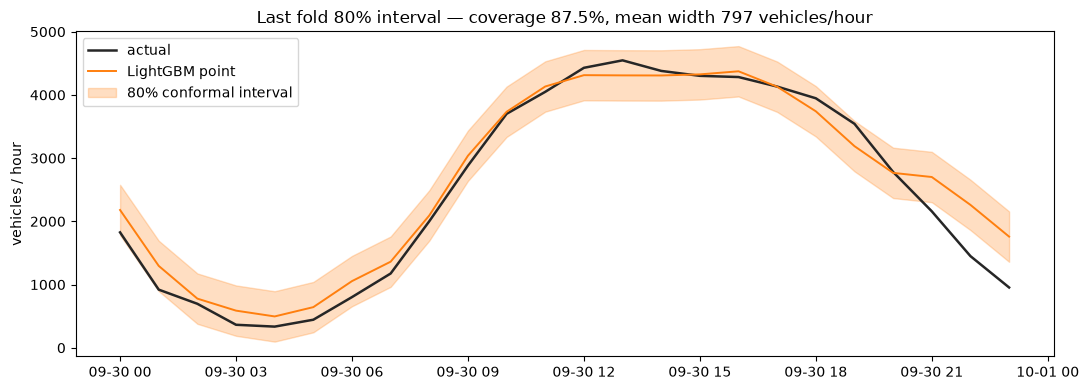

In [20]:
t_te, fold_res, info = interval_last
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_te, fold_res["y_true"], color="0.15", linewidth=1.8, label="actual")
ax.plot(t_te, fold_res["y_pred"], color="C1", linewidth=1.4, label="LightGBM point")
ax.fill_between(
    t_te,
    info["lower"],
    info["upper"],
    color="C1",
    alpha=0.25,
    label="80% conformal interval",
)
ax.set_title(
    f"Last fold 80% interval — coverage {info['coverage']:.1%}, "
    f"mean width {info['width']:.0f} vehicles/hour"
)
ax.set_ylabel("vehicles / hour")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()


### Prophet and sktime on the last expanding fold

Same 24-hour holdout as the last conformal fold, so the three interval methods sit next to each other.


In [21]:
from prophet import Prophet
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.base import ForecastingHorizon
import logging
logging.getLogger("cmdstanpy").disabled = True
logging.getLogger("prophet").setLevel(logging.WARNING)

tr, te = expanding_splits[-1]
y_train_s = y.iloc[tr]
y_true_last = y_arr[te]
t_te = y.index[te]

pdf = pd.DataFrame({"ds": y_train_s.index, "y": y_train_s.to_numpy()})
pm = Prophet(interval_width=0.8, daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
pm.fit(pdf)
future = pm.make_future_dataframe(periods=HORIZON, freq="h")
fcst = pm.predict(future).tail(HORIZON)
prophet_pred = fcst["yhat"].to_numpy()
prophet_lo = fcst["yhat_lower"].to_numpy()
prophet_hi = fcst["yhat_upper"].to_numpy()
print("Prophet last fold")
print("  MAE", round(mae(y_true_last, prophet_pred), 1))
print("  coverage", round(coverage(y_true_last, prophet_lo, prophet_hi), 3))
print("  width", round(interval_width(prophet_lo, prophet_hi), 1))

fh = ForecastingHorizon(t_te, is_relative=False)
sk = NaiveForecaster(strategy="last", sp=PERIOD)
sk.fit(y_train_s)
sk_pred = sk.predict(fh).to_numpy()
sk_int = sk.predict_interval(fh, coverage=0.8)
sk_q = sk.predict_quantiles(fh, alpha=[0.1, 0.5, 0.9])
sk_lo = sk_int.iloc[:, 0].to_numpy()
sk_hi = sk_int.iloc[:, 1].to_numpy()
q10 = sk_q.iloc[:, 0].to_numpy()
q50 = sk_q.iloc[:, 1].to_numpy()
q90 = sk_q.iloc[:, 2].to_numpy()
print("sktime NaiveForecaster last fold")
print("  MAE", round(mae(y_true_last, sk_pred), 1))
print("  coverage", round(coverage(y_true_last, sk_lo, sk_hi), 3))
print("  width", round(interval_width(sk_lo, sk_hi), 1))
print("  pinball 0.1", round(pinball_loss(y_true_last, q10, 0.1), 2))
print("  pinball 0.5", round(pinball_loss(y_true_last, q50, 0.5), 2))
print("  pinball 0.9", round(pinball_loss(y_true_last, q90, 0.9), 2))


Importing plotly failed. Interactive plots will not work.


Prophet last fold
  MAE 796.9
  coverage 0.708
  width 2142.8
sktime NaiveForecaster last fold
  MAE 540.3
  coverage 0.958
  width 2650.0
  pinball 0.1 146.87
  pinball 0.5 270.15
  pinball 0.9 183.84


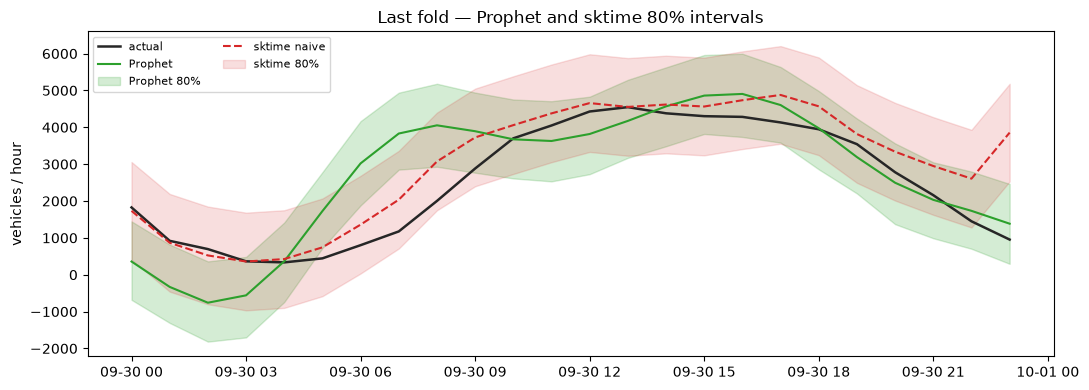

In [22]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_te, y_true_last, color="0.15", linewidth=1.8, label="actual")
ax.plot(t_te, prophet_pred, color="C2", label="Prophet")
ax.fill_between(t_te, prophet_lo, prophet_hi, color="C2", alpha=0.2, label="Prophet 80%")
ax.plot(t_te, sk_pred, color="C3", linestyle="--", label="sktime naive")
ax.fill_between(t_te, sk_lo, sk_hi, color="C3", alpha=0.15, label="sktime 80%")
ax.set_title("Last fold — Prophet and sktime 80% intervals")
ax.set_ylabel("vehicles / hour")
ax.legend(loc="upper left", ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


## 7. What I would use

I compared statsmodels (Holt-Winters and SARIMAX), LightGBM, Prophet, and sktime, plus seasonal-naive as the floor.

**statsmodels.** History is long enough for both ETS and SARIMAX. Holt-Winters is the readable daily-cycle model; it also failed on weekends because period 24 cannot tell Thursday from Saturday. SARIMAX with `d=0` (from ADF) is the ARIMA-family fit. I would not ship either as the point forecast here: expanding MASE was worse than LightGBM, and Ljung-Box still found leftover weekly structure.

**LightGBM.** Enough rows for lags. No native interval, so I wrapped it in conformal residuals. It won the expanding-window MASE and is cheap to refit. That is what I would deploy for this one I-94 sensor, with the 80% conformal band.

**Prophet.** Built for daily data with holidays and multiple seasonalities. On this hourly series it gives an interval for free. I would reach for it if I were forecasting a daily total with Hijri/holiday effects and needed a quick interval, not for an hourly counter where `lag_168` already does the weekly work.

**sktime.** I used `NaiveForecaster(sp=24)` as the interval/quantile API, scored with pinball loss. sktime is an orchestration layer — the useful bit is `predict_interval` / `predict_quantiles` on whatever you wrap. I would use it if I needed one interval API across several estimators. I would not deploy the naive wrapper itself.

**Expanding vs rolling.** Rolling did not beat expanding on this stretch of 2018. No break to age out, so I keep expanding.

**Call.** Expanding-window LightGBM plus the conformal 80% interval. Keep Holt-Winters as a picture of the daily shape, SARIMAX as the ARIMA-family check, Prophet/sktime as interval baselines I would not ship for this series.
